# Multilingual Climate-Stance Ensemble

This notebook evaluates three pretrained sequence-classification models using stratified evaluation folds, soft voting, and weighted soft voting. It also predicts labels for new Hindi/Bangla CSV or Excel files.

## Part 1 — Install dependencies

In [ ]:
# Colab/Jupyter installation cell
%pip install -q -U "transformers>=4.48,<5" "accelerate>=1.2,<2" \
    datasets sentencepiece evaluate scikit-learn openpyxl xlrd joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## Part 2 — Imports, environment, and configuration

In [ ]:
import os
import re
import gc
import json
import math
import hashlib
import warnings
from contextlib import nullcontext
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
# Mount Google Drive only when running in Colab.
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab; Drive mounting was skipped.")

Mounted at /content/drive


In [ ]:
# -----------------------------
# PROJECT CONFIGURATION
# -----------------------------

ROOT = Path("/content/drive/MyDrive/new_ensemble") if IN_COLAB else Path.cwd() / "Ensembled"
ROOT.mkdir(parents=True, exist_ok=True)

for folder_name in ["predictions", "folds", "reports", "test_predictions"]:
    (ROOT / folder_name).mkdir(parents=True, exist_ok=True)

# The resolver uses the first existing path in each list.
DATA_PATH_CANDIDATES = {
    "english": [
        Path("/content/English_train_data.csv"),
        Path("/content/English_train_data(1).csv"),
        ROOT / "English_train_data.csv",
    ],
    "hindi": [
        Path("/content/english_to_hindi.csv"),
        Path("/content/english_to_hindi(1).csv"),
        ROOT / "english_to_hindi.csv",
    ],
    "bengali": [
        Path("/content/english_to_bengali.csv"),
        Path("/content/english_to_bengali(1).csv"),
        ROOT / "english_to_bengali.csv",
    ],
    "none": [
        Path("/content/non_climate_none.csv"),
        ROOT / "non_climate_none.csv",
    ],
}

MODEL_PATHS = {
    "Model1": ROOT / "Best_Model_INDICBERT",
    "Model3": ROOT / "Best_Model_MURIL",
    "Model5": ROOT / "Best_Model_XLMR",
}

# Canonical class order used everywhere in this notebook.
CLASS_NAMES = ("AGAINST", "FAVOR", "NONE")
CLASS_TO_ID = {label: index for index, label in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {index: label for label, index in CLASS_TO_ID.items()}

# IMPORTANT: Set the class-index order used when each model was trained.
# Example: ["AGAINST", "FAVOR", "NONE"] means model output 0=AGAINST, 1=FAVOR, 2=NONE.
MODEL_CLASS_ORDER = {
    "Model1": ["AGAINST", "FAVOR", "NONE"],
    "Model3": ["AGAINST", "FAVOR", "NONE"],
    "Model5": ["AGAINST", "FAVOR", "NONE"],
}

MODEL_WEIGHTS = {
    "Model1": 0.885,
    "Model3": 0.888,
    "Model5": 0.854,
}

RANDOM_SEED = 42
N_SPLITS = 3
MAX_LENGTH = 256
INITIAL_BATCH_SIZE = 32
NUM_WORKERS = 0              # Safest value in Colab/Jupyter.
REMOVE_CONFLICTING_TEXTS = True
FORCE_REPREDICT = False      # Set True to overwrite valid cached predictions.
RUN_TEST_PREDICTIONS = True  # Missing test files are skipped safely.

print("Project root:", ROOT)

Project root: /content/drive/MyDrive/new_ensemble


## Part 3 — Validation and text/label utilities

In [ ]:
LABEL_ALIASES = {
    "AGAINST": "AGAINST",
    "OPPOSE": "AGAINST",
    "OPPOSITION": "AGAINST",
    "FAVOR": "FAVOR",
    "FAVOUR": "FAVOR",
    "SUPPORT": "FAVOR",
    "NONE": "NONE",
    "NEUTRAL": "NONE",
    "UNRELATED": "NONE",
}


def normalize_label(value):
    key = str(value).strip().upper()
    return LABEL_ALIASES.get(key, key)


def clean_text(value):
    text = str(value)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[\u200b-\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def resolve_existing_path(candidates, description):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    attempted = "\n".join(f"  - {Path(path)}" for path in candidates)
    raise FileNotFoundError(
        f"Could not find {description}. Checked:\n{attempted}\n"
        "Upload the file or update DATA_PATH_CANDIDATES."
    )


def read_table(path):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type: {suffix}. Use CSV or Excel.")


def find_column(df, aliases, source_name, required=True):
    lookup = {str(column).strip().lower(): column for column in df.columns}
    for alias in aliases:
        key = alias.strip().lower()
        if key in lookup:
            return lookup[key]
    if required:
        raise KeyError(
            f"No matching column found in {source_name}. "
            f"Expected one of {aliases}; available columns are {list(df.columns)}"
        )
    return None


def validate_model_configuration():
    missing_paths = [name for name, path in MODEL_PATHS.items() if not Path(path).exists()]
    if missing_paths:
        details = "\n".join(f"  - {name}: {MODEL_PATHS[name]}" for name in missing_paths)
        raise FileNotFoundError(
            "The following model folders are missing:\n"
            f"{details}\nUpload/copy the models or correct MODEL_PATHS."
        )

    if set(MODEL_WEIGHTS) != set(MODEL_PATHS):
        raise ValueError("MODEL_WEIGHTS keys must exactly match MODEL_PATHS keys.")
    if set(MODEL_CLASS_ORDER) != set(MODEL_PATHS):
        raise ValueError("MODEL_CLASS_ORDER keys must exactly match MODEL_PATHS keys.")
    if any(weight < 0 for weight in MODEL_WEIGHTS.values()):
        raise ValueError("Model weights must be non-negative.")
    if sum(MODEL_WEIGHTS.values()) <= 0:
        raise ValueError("At least one model weight must be positive.")

    for model_name in MODEL_PATHS:
        order = [normalize_label(label) for label in MODEL_CLASS_ORDER[model_name]]
        if len(order) != len(CLASS_NAMES) or set(order) != set(CLASS_NAMES):
            raise ValueError(
                f"MODEL_CLASS_ORDER[{model_name!r}] must contain each canonical class exactly once. "
                f"Received: {order}"
            )

    print("Model paths, weights, and class-order settings are valid.")

## Part 4 — Load and prepare the multilingual dataset

In [ ]:
SOURCE_SPECS = {
    "english": {
        "text_aliases": ["sentence", "comment", "text", "english"],
        "label_aliases": ["label", "stance", "target"],
        "default_label": None,
    },
    "hindi": {
        "text_aliases": ["hindi", "sentence", "comment", "text"],
        "label_aliases": ["label", "stance", "target"],
        "default_label": None,
    },
    "bengali": {
        "text_aliases": ["bengali", "bangla", "sentence", "comment", "text"],
        "label_aliases": ["label", "stance", "target"],
        "default_label": None,
    },
    "none": {
        "text_aliases": ["sentence", "comment", "text"],
        "label_aliases": ["label", "stance", "target"],
        "default_label": "NONE",
    },
}


def load_standardized_source(source_name):
    spec = SOURCE_SPECS[source_name]
    path = resolve_existing_path(DATA_PATH_CANDIDATES[source_name], f"{source_name} dataset")
    raw = read_table(path)

    text_column = find_column(raw, spec["text_aliases"], source_name)
    label_column = find_column(
        raw,
        spec["label_aliases"],
        source_name,
        required=spec["default_label"] is None,
    )

    result = pd.DataFrame({"sentence": raw[text_column]})
    if label_column is None:
        result["label"] = spec["default_label"]
    else:
        result["label"] = raw[label_column]

    result["source"] = source_name
    print(f"{source_name:8s}: {result.shape[0]:,} rows from {path}")
    return result


source_frames = [load_standardized_source(name) for name in SOURCE_SPECS]
train_df = pd.concat(source_frames, ignore_index=True)
print("Combined raw shape:", train_df.shape)

english : 12,771 rows from /content/English_train_data.csv
hindi   : 12,771 rows from /content/english_to_hindi.csv
bengali : 12,771 rows from /content/english_to_bengali.csv
none    : 10,000 rows from /content/non_climate_none.csv
Combined raw shape: (48313, 3)


In [ ]:
# Drop missing values BEFORE string conversion.
train_df = train_df.dropna(subset=["sentence", "label"]).copy()
train_df["sentence"] = train_df["sentence"].map(clean_text)
train_df["label"] = train_df["label"].map(normalize_label)

# Remove empty or placeholder text values.
invalid_text = train_df["sentence"].str.lower().isin({"", "nan", "none", "null"})
train_df = train_df.loc[~invalid_text].copy()

unknown_labels = sorted(set(train_df["label"]) - set(CLASS_NAMES))
if unknown_labels:
    raise ValueError(
        f"Unexpected labels found: {unknown_labels}. "
        f"Update LABEL_ALIASES or correct the source files. Expected: {CLASS_NAMES}"
    )

before = len(train_df)
train_df = train_df.drop_duplicates(subset=["sentence", "label"]).copy()
print(f"Removed {before - len(train_df):,} exact text-label duplicates.")

# Identical text with different labels is ambiguous and can distort evaluation.
conflict_counts = train_df.groupby("sentence")["label"].nunique()
conflicting_sentences = conflict_counts[conflict_counts > 1].index
print(f"Texts with conflicting labels: {len(conflicting_sentences):,}")

if REMOVE_CONFLICTING_TEXTS and len(conflicting_sentences):
    train_df = train_df.loc[~train_df["sentence"].isin(conflicting_sentences)].copy()
    print("Conflicting texts were removed.")

train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
train_df.insert(0, "row_id", np.arange(len(train_df), dtype=np.int64))
train_df["label_id"] = train_df["label"].map(CLASS_TO_ID).astype(np.int64)

if train_df["label_id"].isna().any():
    raise ValueError("Some labels could not be encoded.")

processed_csv = ROOT / "Multilingual_dataset.csv"
processed_pickle = ROOT / "processed_dataset.pkl"
train_df.to_csv(processed_csv, index=False)
train_df.to_pickle(processed_pickle)

with open(ROOT / "label_mapping.json", "w", encoding="utf-8") as file:
    json.dump(CLASS_TO_ID, file, indent=2)

print("Final dataset shape:", train_df.shape)
print("Saved:", processed_csv)
print(train_df["label"].value_counts())
train_df.head()

Removed 436 exact text-label duplicates.
Texts with conflicting labels: 14
Conflicting texts were removed.
Final dataset shape: (47849, 5)
Saved: /content/drive/MyDrive/new_ensemble/Multilingual_dataset.csv
label
NONE       22639
AGAINST    12609
FAVOR      12601
Name: count, dtype: int64


,row_id,sentence,label,source,label_id
0,0,: . जलवायु परिवर्तन नीति पर आपके विचार चाहे जो...,AGAINST,hindi,0
1,1,": बेशक जलवायु परिवर्तन मौजूद है। इसके अलावा, C...",AGAINST,hindi,0
2,2,Funding for climate change research-->Funding ...,NONE,english,2
3,3,ऐसा माना जाता है कि खतरनाक कचरा ग्रीनलैंड की ब...,FAVOR,hindi,1
4,4,আমরা যে কোনো সমস্যার পরম সমাধান পেতে পারি; ক্ষ...,FAVOR,bengali,1


## Part 5 — Create or validate three stratified evaluation folds

In [ ]:
def dataset_fingerprint(frame):
    hashed = pd.util.hash_pandas_object(
        frame[["sentence", "label_id"]], index=False
    ).values.tobytes()
    return hashlib.sha256(hashed).hexdigest()


def create_or_load_folds(frame, fold_path, n_splits=N_SPLITS):
    fingerprint = dataset_fingerprint(frame)
    fold_path = Path(fold_path)

    if fold_path.exists():
        artifact = joblib.load(fold_path)
        valid = (
            isinstance(artifact, dict)
            and artifact.get("fingerprint") == fingerprint
            and artifact.get("n_rows") == len(frame)
            and artifact.get("n_splits") == n_splits
            and len(artifact.get("folds", [])) == n_splits
        )
        if valid:
            print("Loaded valid cached folds:", fold_path)
            return artifact["folds"]
        print("Cached folds do not match the current dataset; recreating them.")

    min_class_count = frame["label_id"].value_counts().min()
    if min_class_count < n_splits:
        raise ValueError(
            f"The smallest class has only {min_class_count} rows, "
            f"which is insufficient for {n_splits} stratified folds."
        )

    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    folds = []
    for train_index, validation_index in splitter.split(frame["sentence"], frame["label_id"]):
        folds.append({
            "train_idx": train_index.astype(np.int64),
            "val_idx": validation_index.astype(np.int64),
        })

    artifact = {
        "fingerprint": fingerprint,
        "n_rows": len(frame),
        "n_splits": n_splits,
        "folds": folds,
    }
    joblib.dump(artifact, fold_path)
    print("Created and saved new folds:", fold_path)
    return folds


fold_file = ROOT / "folds" / "fold_indices.pkl"
folds = create_or_load_folds(train_df, fold_file)

for fold_number, fold in enumerate(folds, start=1):
    validation_labels = train_df.iloc[fold["val_idx"]]["label"].value_counts().to_dict()
    print(
        f"Fold {fold_number}: train={len(fold['train_idx']):,}, "
        f"validation={len(fold['val_idx']):,}, distribution={validation_labels}"
    )

Loaded valid cached folds: /content/drive/MyDrive/new_ensemble/folds/fold_indices.pkl
Fold 1: train=31,899, validation=15,950, distribution={'NONE': 7547, 'AGAINST': 4203, 'FAVOR': 4200}
Fold 2: train=31,899, validation=15,950, distribution={'NONE': 7546, 'AGAINST': 4203, 'FAVOR': 4201}
Fold 3: train=31,900, validation=15,949, distribution={'NONE': 7546, 'AGAINST': 4203, 'FAVOR': 4200}


## Part 6 — Memory-efficient prediction helpers

In [ ]:
class TextPredictionDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.texts = [str(text) for text in texts]
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        return self.tokenizer(
            self.texts[index],
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except RuntimeError:
            pass


def decode_ids(values):
    values = np.asarray(values, dtype=np.int64)
    invalid = values[(values < 0) | (values >= len(CLASS_NAMES))]
    if len(invalid):
        raise ValueError(f"Prediction IDs outside valid range: {np.unique(invalid)}")
    return np.asarray([ID_TO_CLASS[int(value)] for value in values], dtype=object)


def align_probabilities(probabilities, source_order):
    source_order = [normalize_label(label) for label in source_order]
    if probabilities.ndim != 2:
        raise ValueError(f"Expected a 2D probability array, got shape {probabilities.shape}")
    if probabilities.shape[1] != len(source_order):
        raise ValueError(
            f"Model produced {probabilities.shape[1]} columns but source order has "
            f"{len(source_order)} labels."
        )

    aligned = np.zeros((len(probabilities), len(CLASS_NAMES)), dtype=np.float32)
    for source_index, class_name in enumerate(source_order):
        aligned[:, CLASS_TO_ID[class_name]] = probabilities[:, source_index]

    row_sums = aligned.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-4):
        warnings.warn("Aligned probabilities do not sum to 1 within tolerance.")
    return aligned


def is_cuda_oom(error):
    return isinstance(error, torch.cuda.OutOfMemoryError) or (
        isinstance(error, RuntimeError) and "out of memory" in str(error).lower()
    )

In [ ]:
def predict_model(model_name, model_path, texts, batch_size=INITIAL_BATCH_SIZE, max_length=MAX_LENGTH):
    if not texts:
        raise ValueError("No texts were supplied for prediction.")

    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Model path does not exist: {model_path}")

    print(f"Loading {model_name}: {model_path}")
    try:
        tokenizer = AutoTokenizer.from_pretrained(str(model_path), use_fast=True)
    except Exception as fast_tokenizer_error:
        warnings.warn(
            f"Fast tokenizer loading failed for {model_name}; using the slow tokenizer. "
            f"Original error: {fast_tokenizer_error}"
        )
        tokenizer = AutoTokenizer.from_pretrained(str(model_path), use_fast=False)

    model = AutoModelForSequenceClassification.from_pretrained(
        str(model_path),
        low_cpu_mem_usage=True,
    )

    if int(model.config.num_labels) != len(CLASS_NAMES):
        raise ValueError(
            f"{model_name} has {model.config.num_labels} output labels, "
            f"but this notebook expects {len(CLASS_NAMES)}."
        )

    source_order = MODEL_CLASS_ORDER[model_name]
    model.to(DEVICE)
    model.eval()

    dataset = TextPredictionDataset(texts, tokenizer, max_length)
    collator = DataCollatorWithPadding(
        tokenizer=tokenizer,
        pad_to_multiple_of=8 if DEVICE.type == "cuda" else None,
        return_tensors="pt",
    )

    current_batch_size = max(1, int(batch_size))
    try:
        while True:
            loader = DataLoader(
                dataset,
                batch_size=current_batch_size,
                shuffle=False,
                num_workers=NUM_WORKERS,
                pin_memory=DEVICE.type == "cuda",
                collate_fn=collator,
            )
            chunks = []
            try:
                with torch.inference_mode():
                    for batch in loader:
                        batch = {
                            key: value.to(DEVICE, non_blocking=DEVICE.type == "cuda")
                            for key, value in batch.items()
                        }
                        amp_context = (
                            torch.autocast(device_type="cuda", dtype=torch.float16)
                            if DEVICE.type == "cuda"
                            else nullcontext()
                        )
                        with amp_context:
                            logits = model(**batch).logits
                        probabilities = torch.softmax(logits.float(), dim=-1)
                        chunks.append(probabilities.cpu().numpy())

                raw_probabilities = np.concatenate(chunks, axis=0)
                if len(raw_probabilities) != len(texts):
                    raise RuntimeError(
                        f"Expected {len(texts)} predictions, received {len(raw_probabilities)}."
                    )
                aligned_probabilities = align_probabilities(raw_probabilities, source_order)
                prediction_ids = aligned_probabilities.argmax(axis=1).astype(np.int64)
                print(f"{model_name} completed with batch size {current_batch_size}.")
                return aligned_probabilities, prediction_ids

            except Exception as error:
                if is_cuda_oom(error) and current_batch_size > 1:
                    current_batch_size = max(1, current_batch_size // 2)
                    print(f"CUDA memory limit reached; retrying {model_name} with batch size {current_batch_size}.")
                    chunks.clear()
                    try:
                        del batch, logits, probabilities
                    except UnboundLocalError:
                        pass
                    clear_memory()
                    continue
                raise
    finally:
        del model
        del tokenizer
        clear_memory()

In [ ]:
def prediction_paths(fold_folder, model_name):
    fold_folder = Path(fold_folder)
    return (
        fold_folder / f"{model_name}_prob.npy",
        fold_folder / f"{model_name}_predictions.csv",
    )


def prediction_cache_is_valid(fold_folder, model_name, expected_rows):
    probability_path, table_path = prediction_paths(fold_folder, model_name)
    if not probability_path.exists() or not table_path.exists():
        return False
    try:
        probabilities = np.load(probability_path, mmap_mode="r")
        table = pd.read_csv(table_path)
        return (
            probabilities.shape == (expected_rows, len(CLASS_NAMES))
            and len(table) == expected_rows
            and {"prediction_id", "prediction", "confidence"}.issubset(table.columns)
        )
    except Exception:
        return False


def save_model_predictions(fold_folder, model_name, probabilities, prediction_ids):
    fold_folder = Path(fold_folder)
    fold_folder.mkdir(parents=True, exist_ok=True)
    probability_path, table_path = prediction_paths(fold_folder, model_name)

    probability_temp = probability_path.with_suffix(".tmp.npy")
    table_temp = table_path.with_suffix(".tmp.csv")

    np.save(probability_temp, probabilities)
    pd.DataFrame({
        "prediction_id": prediction_ids.astype(np.int64),
        "prediction": decode_ids(prediction_ids),
        "confidence": probabilities.max(axis=1),
    }).to_csv(table_temp, index=False)

    os.replace(probability_temp, probability_path)
    os.replace(table_temp, table_path)

## Part 7 — Run fold-wise predictions for all models


In [ ]:
validate_model_configuration()

for fold_number, fold in enumerate(folds, start=1):
    print("=" * 70)
    print(f"FOLD {fold_number}/{N_SPLITS}")
    print("=" * 70)

    validation_df = train_df.iloc[fold["val_idx"]].reset_index(drop=True).copy()
    fold_folder = ROOT / "predictions" / f"fold_{fold_number}"
    fold_folder.mkdir(parents=True, exist_ok=True)

    texts = validation_df["sentence"].tolist()
    for model_name, model_path in MODEL_PATHS.items():
        if not FORCE_REPREDICT and prediction_cache_is_valid(
            fold_folder, model_name, len(validation_df)
        ):
            print(f"Skipping {model_name}: valid cached predictions found.")
            continue

        probabilities, prediction_ids = predict_model(
            model_name=model_name,
            model_path=model_path,
            texts=texts,
        )
        save_model_predictions(
            fold_folder,
            model_name,
            probabilities,
            prediction_ids,
        )

print("All fold predictions are available.")


Model paths, weights, and class-order settings are valid.
FOLD 1/3
Loading Model1: /content/drive/MyDrive/new_ensemble/Best_Model_INDICBERT
Model1 completed with batch size 32.
Loading Model3: /content/drive/MyDrive/new_ensemble/Best_Model_MURIL
Model3 completed with batch size 32.
Loading Model5: /content/drive/MyDrive/new_ensemble/Best_Model_XLMR
Model5 completed with batch size 32.
FOLD 2/3
Loading Model1: /content/drive/MyDrive/new_ensemble/Best_Model_INDICBERT
Model1 completed with batch size 32.
Loading Model3: /content/drive/MyDrive/new_ensemble/Best_Model_MURIL
Model3 completed with batch size 32.
Loading Model5: /content/drive/MyDrive/new_ensemble/Best_Model_XLMR
Model5 completed with batch size 32.
FOLD 3/3
Loading Model1: /content/drive/MyDrive/new_ensemble/Best_Model_INDICBERT
Model1 completed with batch size 32.
Loading Model3: /content/drive/MyDrive/new_ensemble/Best_Model_MURIL
Model3 completed with batch size 32.
Loading Model5: /content/drive/MyDrive/new_ensemble/Best_

## Part 8 — Soft voting and weighted soft voting


In [ ]:
weight_total = sum(MODEL_WEIGHTS.values())
NORMALIZED_WEIGHTS = {
    model_name: weight / weight_total
    for model_name, weight in MODEL_WEIGHTS.items()
}
print("Normalized weights:", NORMALIZED_WEIGHTS)


def soft_voting(probability_list):
    average_probability = np.mean(np.stack(probability_list, axis=0), axis=0)
    prediction_ids = average_probability.argmax(axis=1).astype(np.int64)
    confidence = average_probability.max(axis=1)
    return average_probability, prediction_ids, confidence


def weighted_soft_voting(probabilities_by_model):
    weighted_probability = np.zeros_like(next(iter(probabilities_by_model.values())), dtype=np.float32)
    for model_name, probabilities in probabilities_by_model.items():
        weighted_probability += NORMALIZED_WEIGHTS[model_name] * probabilities
    prediction_ids = weighted_probability.argmax(axis=1).astype(np.int64)
    confidence = weighted_probability.max(axis=1)
    return weighted_probability, prediction_ids, confidence


def agreement_description(max_votes, number_of_models):
    if max_votes == number_of_models:
        return f"{max_votes}/{number_of_models} Unanimous"
    if max_votes >= math.ceil(0.8 * number_of_models):
        return f"{max_votes}/{number_of_models} Strong Majority"
    if max_votes > number_of_models / 2:
        return f"{max_votes}/{number_of_models} Majority"
    return f"{max_votes}/{number_of_models} Weak/Plurality"

Normalized weights: {'Model1': 0.3368861819566045, 'Model3': 0.33802816901408456, 'Model5': 0.32508564902931103}


In [ ]:
# Load the combined multilingual dataset created
if not Path(processed_csv).exists():
    raise FileNotFoundError(
        f"The multilingual dataset was not found: {processed_csv}\n"
        "Run Part 4 before running the ensemble section."
    )

multilingual_dataset = pd.read_csv(processed_csv)

required_dataset_columns = {"row_id", "sentence", "label", "label_id"}
missing_dataset_columns = required_dataset_columns - set(multilingual_dataset.columns)
if missing_dataset_columns:
    raise ValueError(
        f"The multilingual dataset is missing required columns: "
        f"{sorted(missing_dataset_columns)}"
    )

if len(multilingual_dataset) != len(train_df):
    raise ValueError(
        "Multilingual_dataset.csv and train_df have different row counts. "
        "Run Parts 4 and 5 again before creating ensemble predictions."
    )

if not np.array_equal(
    multilingual_dataset["row_id"].astype(np.int64).to_numpy(),
    train_df["row_id"].astype(np.int64).to_numpy(),
):
    raise ValueError(
        "The row order in Multilingual_dataset.csv does not match train_df. "
        "Run Parts 4 and 5 again to recreate the dataset and fold indices."
    )

for fold_number, fold in enumerate(folds, start=1):
    fold_folder = ROOT / "predictions" / f"fold_{fold_number}"
    fold_folder.mkdir(parents=True, exist_ok=True)

    # Select only the rows assigned to this fold's validation partition.
    validation = (
        multilingual_dataset
        .iloc[fold["val_idx"]]
        .reset_index(drop=True)
        .copy()
    )

    probabilities_by_model = {}
    model_prediction_columns = []

    for model_name in MODEL_PATHS:
        probability_path, prediction_path = prediction_paths(fold_folder, model_name)

        missing_model_files = [
            str(path)
            for path in (probability_path, prediction_path)
            if not path.exists()
        ]
        if missing_model_files:
            missing_text = "\n".join(f"  - {path}" for path in missing_model_files)
            raise FileNotFoundError(
                f"Missing prediction files for {model_name}, fold {fold_number}:\n"
                f"{missing_text}\n"
                "Run Part 7 first. If an old cache is incomplete, set "
                "FORCE_REPREDICT=True and rerun Part 7."
            )

        probabilities = np.load(probability_path)
        prediction_table = pd.read_csv(prediction_path)

        expected_shape = (len(validation), len(CLASS_NAMES))
        if probabilities.shape != expected_shape:
            raise ValueError(
                f"Invalid probability shape for {model_name}, fold {fold_number}. "
                f"Found {probabilities.shape}; expected {expected_shape}. "
                "Set FORCE_REPREDICT=True and rerun Part 7."
            )

        required_prediction_columns = {"prediction", "prediction_id", "confidence"}
        missing_prediction_columns = (
            required_prediction_columns - set(prediction_table.columns)
        )
        if missing_prediction_columns:
            raise ValueError(
                f"{prediction_path} is missing columns: "
                f"{sorted(missing_prediction_columns)}"
            )

        if len(prediction_table) != len(validation):
            raise ValueError(
                f"Prediction row mismatch for {model_name}, fold {fold_number}. "
                f"Found {len(prediction_table)} rows; expected {len(validation)}. "
                "Set FORCE_REPREDICT=True and rerun Part 7."
            )

        prediction_ids = prediction_table["prediction_id"].astype(np.int64).to_numpy()
        if not np.array_equal(prediction_ids, probabilities.argmax(axis=1)):
            raise ValueError(
                f"The cached prediction IDs and probability file disagree for "
                f"{model_name}, fold {fold_number}. Set FORCE_REPREDICT=True "
                "and rerun Part 7."
            )

        probabilities_by_model[model_name] = probabilities
        prediction_column = f"{model_name}_Prediction"
        validation[prediction_column] = prediction_table["prediction"].values
        validation[f"{model_name}_Prediction_ID"] = prediction_ids
        validation[f"{model_name}_Confidence"] = (
            prediction_table["confidence"].astype(float).values
        )
        model_prediction_columns.append(prediction_column)

    soft_probability, soft_ids, soft_confidence = soft_voting(
        list(probabilities_by_model.values())
    )
    weighted_probability, weighted_ids, weighted_confidence = weighted_soft_voting(
        probabilities_by_model
    )

    validation["SoftVote_ID"] = soft_ids
    validation["SoftVote"] = decode_ids(soft_ids)
    validation["SoftConfidence"] = soft_confidence
    validation["WeightedVote_ID"] = weighted_ids
    validation["WeightedVote"] = decode_ids(weighted_ids)
    validation["WeightedConfidence"] = weighted_confidence

    for class_index, class_name in enumerate(CLASS_NAMES):
        validation[f"Soft_{class_name}_Probability"] = soft_probability[:, class_index]
        validation[f"Weighted_{class_name}_Probability"] = (
            weighted_probability[:, class_index]
        )
        validation[f"{class_name}_Votes"] = (
            validation[model_prediction_columns] == class_name
        ).sum(axis=1)

    vote_columns = [f"{class_name}_Votes" for class_name in CLASS_NAMES]
    validation["Agreement"] = validation[vote_columns].max(axis=1).astype(int)
    validation["Agreement_Type"] = validation["Agreement"].map(
        lambda value: agreement_description(int(value), len(MODEL_PATHS))
    )

    output_path = fold_folder / "ensemble_predictions.csv"
    temporary_output_path = fold_folder / "ensemble_predictions.tmp.csv"
    validation.to_csv(temporary_output_path, index=False)
    os.replace(temporary_output_path, output_path)
    print(f"Saved fold {fold_number}: {output_path}")

print("All ensemble prediction files were created successfully.")


Saved fold 1: /content/drive/MyDrive/new_ensemble/predictions/fold_1/ensemble_predictions.csv
Saved fold 2: /content/drive/MyDrive/new_ensemble/predictions/fold_2/ensemble_predictions.csv
Saved fold 3: /content/drive/MyDrive/new_ensemble/predictions/fold_3/ensemble_predictions.csv
All ensemble prediction files were created successfully.


## Part 9 — Evaluate every model and both ensemble methods

In [ ]:
def evaluate_predictions(true_ids, predicted_ids):
    return {
        "Accuracy": accuracy_score(true_ids, predicted_ids),
        "Precision": precision_score(
            true_ids, predicted_ids, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            true_ids, predicted_ids, average="weighted", zero_division=0
        ),
        "F1": f1_score(
            true_ids, predicted_ids, average="weighted", zero_division=0
        ),
    }


ensemble_paths = [
    ROOT / "predictions" / f"fold_{fold_number}" / "ensemble_predictions.csv"
    for fold_number in range(1, N_SPLITS + 1)
]
missing_ensemble_paths = [path for path in ensemble_paths if not path.exists()]
if missing_ensemble_paths:
    missing_text = "\n".join(f"  - {path}" for path in missing_ensemble_paths)
    raise FileNotFoundError(
        "The following ensemble files have not been created:\n"
        f"{missing_text}\n"
        "Run Part 7 and then Part 8 before running evaluation."
    )

fold_results = []
for fold_number, ensemble_path in enumerate(ensemble_paths, start=1):
    ensemble = pd.read_csv(ensemble_path)
    true_ids = ensemble["label_id"].astype(int).to_numpy()

    for model_name in MODEL_PATHS:
        predicted_ids = ensemble[f"{model_name}_Prediction_ID"].astype(int).to_numpy()
        row = evaluate_predictions(true_ids, predicted_ids)
        row.update({"Fold": fold_number, "Model": model_name})
        fold_results.append(row)

    for display_name, column in [
        ("SoftVoting", "SoftVote_ID"),
        ("WeightedSoftVoting", "WeightedVote_ID"),
    ]:
        predicted_ids = ensemble[column].astype(int).to_numpy()
        row = evaluate_predictions(true_ids, predicted_ids)
        row.update({"Fold": fold_number, "Model": display_name})
        fold_results.append(row)

results_df = pd.DataFrame(fold_results)[
    ["Fold", "Model", "Accuracy", "Precision", "Recall", "F1"]
]
average_results = (
    results_df.groupby("Model", as_index=False)[["Accuracy", "Precision", "Recall", "F1"]]
    .mean()
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

results_df.to_csv(ROOT / "reports" / "Model_Comparison_By_Fold.csv", index=False)
average_results.to_csv(ROOT / "reports" / "Average_Model_Performance.csv", index=False)

display(results_df)
display(average_results)


,Fold,Model,Accuracy,Precision,Recall,F1
0,1,Model1,0.934107,0.936282,0.934107,0.934211
1,1,Model3,0.928276,0.931619,0.928276,0.928486
2,1,Model5,0.925893,0.928673,0.925893,0.926061
3,1,SoftVoting,0.958307,0.959865,0.958307,0.958312
4,1,WeightedSoftVoting,0.958307,0.959886,0.958307,0.958313
5,2,Model1,0.938871,0.940868,0.938871,0.939022
6,2,Model3,0.929906,0.932753,0.929906,0.930114
7,2,Model5,0.925643,0.928134,0.925643,0.925804
8,2,SoftVoting,0.959687,0.961446,0.959687,0.959718
9,2,WeightedSoftVoting,0.960063,0.961807,0.960063,0.960094


,Model,Accuracy,Precision,Recall,F1
0,WeightedSoftVoting,0.959080,0.960695,0.959080,0.959093
1,SoftVoting,0.958954,0.960571,0.958954,0.958968
2,Model1,0.936321,0.938300,0.936321,0.936436
3,Model3,0.929236,0.932272,0.929236,0.929435
4,Model5,0.925286,0.927928,0.925286,0.925460


In [ ]:
# Merge all folds into one out-of-fold-style evaluation table.
ensemble_paths = [
    ROOT / "predictions" / f"fold_{fold_number}" / "ensemble_predictions.csv"
    for fold_number in range(1, N_SPLITS + 1)
]
missing_ensemble_paths = [path for path in ensemble_paths if not path.exists()]
if missing_ensemble_paths:
    missing_text = "\n".join(f"  - {path}" for path in missing_ensemble_paths)
    raise FileNotFoundError(
        "The following ensemble files have not been created:\n"
        f"{missing_text}\n"
        "Run Part 7 and then Part 8 before running this merge cell."
    )

merged_frames = []
for fold_number, ensemble_path in enumerate(ensemble_paths, start=1):
    frame = pd.read_csv(ensemble_path)
    frame["Fold"] = fold_number
    merged_frames.append(frame)

merged = (
    pd.concat(merged_frames, ignore_index=True)
    .sort_values("row_id")
    .reset_index(drop=True)
)

if merged["row_id"].duplicated().any() or len(merged) != len(train_df):
    raise RuntimeError(
        "Merged fold predictions do not form a one-to-one partition of the dataset."
    )

final_prediction_path = ROOT / "Final_Ensemble_Predictions.csv"
merged.to_csv(final_prediction_path, index=False)
print("Merged shape:", merged.shape)
print("Saved:", final_prediction_path)


Merged shape: (47849, 32)
Saved: /content/drive/MyDrive/new_ensemble/Final_Ensemble_Predictions.csv


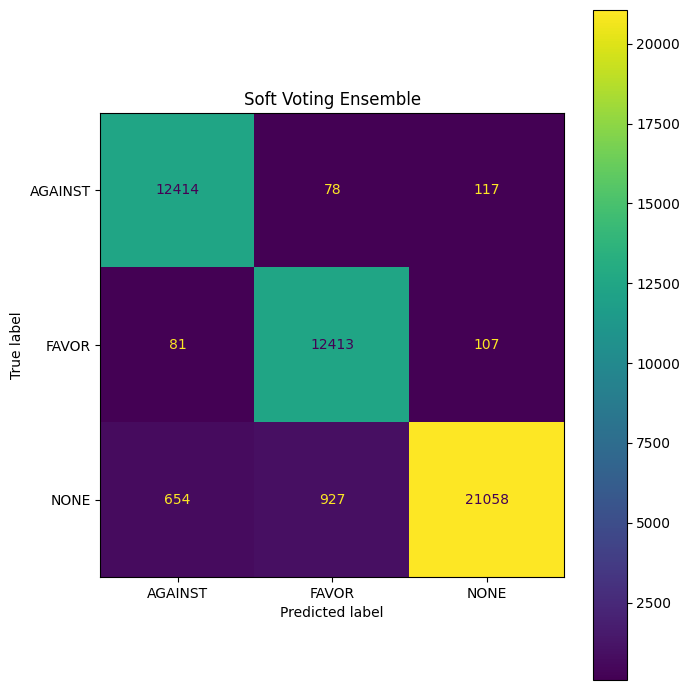

Soft Voting Ensemble


,Model,Accuracy,Precision,Recall,F1
0,Soft Voting Ensemble,0.958954,0.960565,0.958954,0.958967


,precision,recall,f1-score,support
AGAINST,0.944102,0.984535,0.963895,12609.000000
FAVOR,0.925101,0.985081,0.954149,12601.000000
NONE,0.989475,0.930165,0.958903,22639.000000
accuracy,0.958954,0.958954,0.958954,0.958954
macro avg,0.952892,0.966593,0.958982,47849.000000
weighted avg,0.960565,0.958954,0.958967,47849.000000


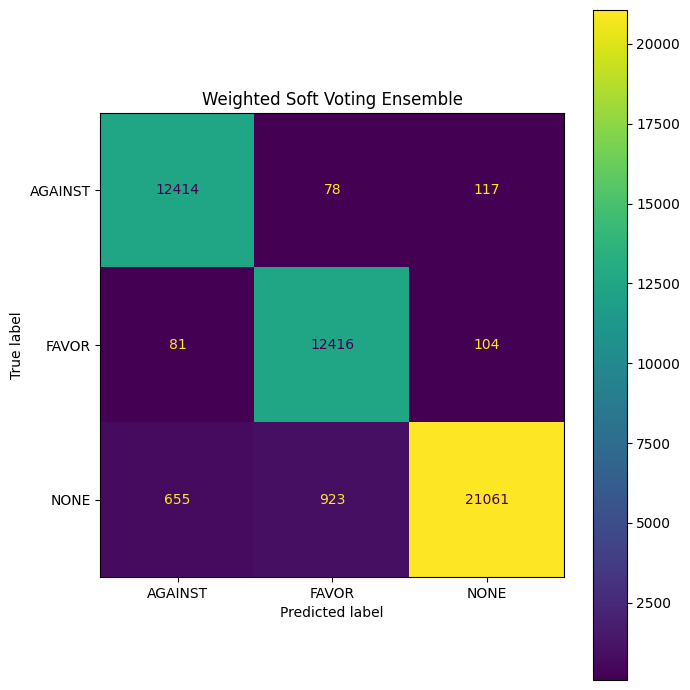

Weighted Soft Voting Ensemble


,Model,Accuracy,Precision,Recall,F1
0,Weighted Soft Voting Ensemble,0.95908,0.96069,0.95908,0.959092


,precision,recall,f1-score,support
AGAINST,0.944030,0.984535,0.963857,12609.00000
FAVOR,0.925393,0.985319,0.954416,12601.00000
NONE,0.989616,0.930297,0.959040,22639.00000
accuracy,0.959080,0.959080,0.959080,0.95908
macro avg,0.953013,0.966717,0.959105,47849.00000
weighted avg,0.960690,0.959080,0.959092,47849.00000


In [ ]:
def save_ensemble_report(frame, prediction_id_column, model_display_name, file_prefix):
    true_ids = frame["label_id"].astype(int).to_numpy()
    predicted_ids = frame[prediction_id_column].astype(int).to_numpy()

    metrics = evaluate_predictions(true_ids, predicted_ids)
    metrics_table = pd.DataFrame([{"Model": model_display_name, **metrics}])
    metrics_table.to_csv(ROOT / "reports" / f"{file_prefix}_Metrics.csv", index=False)

    report = classification_report(
        true_ids,
        predicted_ids,
        labels=list(range(len(CLASS_NAMES))),
        target_names=list(CLASS_NAMES),
        zero_division=0,
        output_dict=True,
    )
    report_table = pd.DataFrame(report).transpose()
    report_table.to_csv(ROOT / "reports" / f"{file_prefix}_Classification_Report.csv")

    matrix = confusion_matrix(
        true_ids,
        predicted_ids,
        labels=list(range(len(CLASS_NAMES))),
    )
    figure, axis = plt.subplots(figsize=(7, 7))
    display_matrix = ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES)
    display_matrix.plot(ax=axis, values_format="d")
    axis.set_title(model_display_name)
    figure.tight_layout()
    figure.savefig(ROOT / "reports" / f"{file_prefix}_Confusion_Matrix.png", dpi=200)
    plt.show()

    print(model_display_name)
    display(metrics_table)
    display(report_table)
    return metrics_table, report_table


soft_metrics, soft_report = save_ensemble_report(
    merged, "SoftVote_ID", "Soft Voting Ensemble", "SoftVoting"
)
weighted_metrics, weighted_report = save_ensemble_report(
    merged, "WeightedVote_ID", "Weighted Soft Voting Ensemble", "WeightedSoftVoting"
)

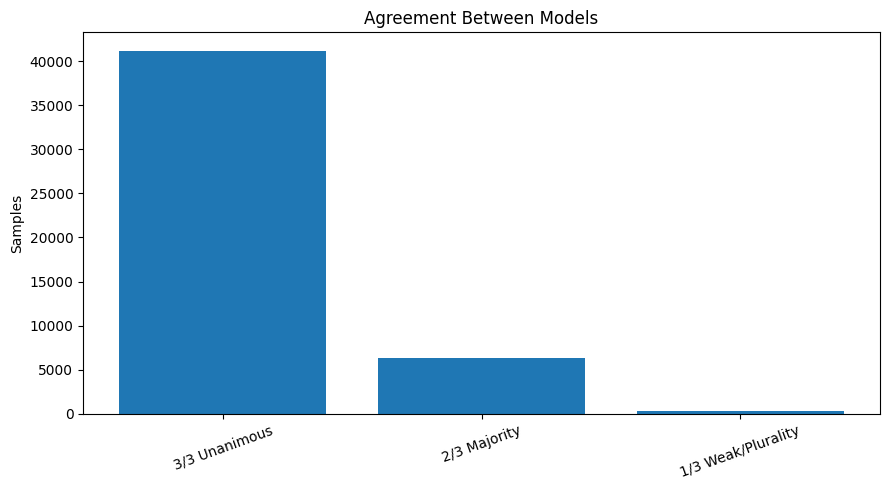

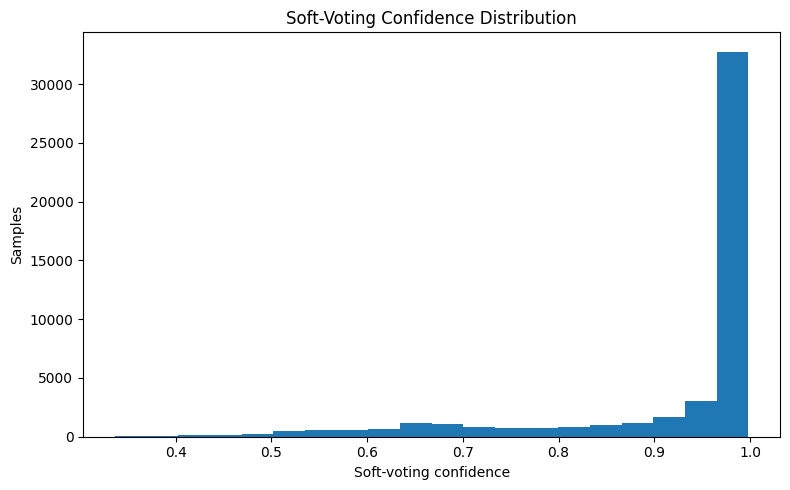

,Agreement,Samples,Percentage
0,3/3 Unanimous,41194,86.091663
1,2/3 Majority,6308,13.183139
2,1/3 Weak/Plurality,347,0.725198


,Predicted_Class,Average_Confidence
0,AGAINST,0.927656
1,FAVOR,0.927175
2,NONE,0.919697


In [ ]:
# Agreement and confidence analyses.
agreement = (
    merged["Agreement_Type"]
    .value_counts()
    .rename_axis("Agreement")
    .reset_index(name="Samples")
)
agreement["Percentage"] = 100 * agreement["Samples"] / len(merged)
agreement.to_csv(ROOT / "reports" / "Agreement_Analysis.csv", index=False)

figure, axis = plt.subplots(figsize=(9, 5))
axis.bar(agreement["Agreement"], agreement["Samples"])
axis.set_ylabel("Samples")
axis.set_title("Agreement Between Models")
axis.tick_params(axis="x", rotation=20)
figure.tight_layout()
figure.savefig(ROOT / "reports" / "Agreement_Plot.png", dpi=200)
plt.show()

figure, axis = plt.subplots(figsize=(8, 5))
axis.hist(merged["SoftConfidence"], bins=20)
axis.set_xlabel("Soft-voting confidence")
axis.set_ylabel("Samples")
axis.set_title("Soft-Voting Confidence Distribution")
figure.tight_layout()
figure.savefig(ROOT / "reports" / "SoftVoting_Confidence_Distribution.png", dpi=200)
plt.show()

average_confidence = (
    merged.groupby("SoftVote", as_index=False)["SoftConfidence"]
    .mean()
    .rename(columns={"SoftVote": "Predicted_Class", "SoftConfidence": "Average_Confidence"})
)
average_confidence.to_csv(ROOT / "reports" / "Average_Confidence_By_Class.csv", index=False)

display(agreement)
display(average_confidence)

## Part 10 — Predict a new CSV or Excel file

In [ ]:
def detect_text_column(frame, requested_column=None):
    if requested_column is not None:
        if requested_column not in frame.columns:
            raise KeyError(
                f"Requested text column {requested_column!r} is missing. "
                f"Available columns: {list(frame.columns)}"
            )
        return requested_column

    return find_column(
        frame,
        aliases=["COMMENT", "comment", "sentence", "text", "hindi", "bengali", "bangla"],
        source_name="test file",
        required=True,
    )


def predict_new_file(input_path, output_path, text_column=None):
    input_path = Path(input_path)
    output_path = Path(output_path)

    if not input_path.exists():
        print(f"Skipping missing test file: {input_path}")
        return None

    test_df = read_table(input_path)
    if test_df.empty:
        raise ValueError(f"The test file contains no rows: {input_path}")
    selected_text_column = detect_text_column(test_df, text_column)

    missing_mask = test_df[selected_text_column].isna()
    if missing_mask.any():
        warnings.warn(
            f"{int(missing_mask.sum())} missing text values will be converted to empty strings."
        )

    texts = test_df[selected_text_column].fillna("").map(clean_text).tolist()
    probabilities_by_model = {}
    model_prediction_columns = []

    for model_name, model_path in MODEL_PATHS.items():
        probabilities, prediction_ids = predict_model(
            model_name=model_name,
            model_path=model_path,
            texts=texts,
        )
        probabilities_by_model[model_name] = probabilities
        prediction_column = f"{model_name}_Prediction"
        test_df[prediction_column] = decode_ids(prediction_ids)
        test_df[f"{model_name}_Prediction_ID"] = prediction_ids
        test_df[f"{model_name}_Confidence"] = probabilities.max(axis=1)
        model_prediction_columns.append(prediction_column)

    soft_probability, soft_ids, soft_confidence = soft_voting(list(probabilities_by_model.values()))
    weighted_probability, weighted_ids, weighted_confidence = weighted_soft_voting(probabilities_by_model)

    test_df["Final_Ensemble_Label"] = decode_ids(soft_ids)
    test_df["Final_Ensemble_Label_ID"] = soft_ids
    test_df["Final_Confidence"] = soft_confidence
    test_df["Weighted_Ensemble_Label"] = decode_ids(weighted_ids)
    test_df["Weighted_Ensemble_Label_ID"] = weighted_ids
    test_df["Weighted_Confidence"] = weighted_confidence

    for class_index, class_name in enumerate(CLASS_NAMES):
        test_df[f"{class_name}_Probability"] = soft_probability[:, class_index]
        test_df[f"Weighted_{class_name}_Probability"] = weighted_probability[:, class_index]
        test_df[f"{class_name}_Votes"] = (
            test_df[model_prediction_columns] == class_name
        ).sum(axis=1)

    vote_columns = [f"{class_name}_Votes" for class_name in CLASS_NAMES]
    test_df["Agreement"] = test_df[vote_columns].max(axis=1).astype(int)
    test_df["Agreement_Type"] = test_df["Agreement"].map(
        lambda value: agreement_description(int(value), len(MODEL_PATHS))
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.suffix.lower() in {".xlsx", ".xls"}:
        test_df.to_excel(output_path, index=False)
    else:
        test_df.to_csv(output_path, index=False)

    print(f"Saved {len(test_df):,} predictions to: {output_path}")
    return test_df

In [ ]:
# Add, remove, or edit jobs here. Missing input files are skipped without stopping the notebook.
TEST_JOBS = [
    {
        "input_candidates": [
            Path("/content/Hindi_500_test data.xlsx"),
            Path("/content/Hindi_500_test data(1).xlsx"),
        ],
        "output": ROOT / "test_predictions" / "Predicted_Comments_Hindi.csv",
        "text_column": None,
    },
    {
        "input_candidates": [
            Path("/content/Bangla_500_test data.xlsx"),
            Path("/content/Bangla_500_test data(1).xlsx"),
        ],
        "output": ROOT / "test_predictions" / "Predicted_Comments_Bangla.csv",
        "text_column": None,
    },
]

if RUN_TEST_PREDICTIONS:
    for job in TEST_JOBS:
        existing_input = next((path for path in job["input_candidates"] if Path(path).exists()), None)
        if existing_input is None:
            print("Skipping job; none of these files exist:")
            for candidate in job["input_candidates"]:
                print("  -", candidate)
            continue

        predicted_frame = predict_new_file(
            input_path=existing_input,
            output_path=job["output"],
            text_column=job["text_column"],
        )
        if predicted_frame is not None:
            display(predicted_frame.head())
else:
    print("RUN_TEST_PREDICTIONS is False; test-file prediction was skipped.")

Loading Model1: /content/drive/MyDrive/new_ensemble/Best_Model_INDICBERT
Model1 completed with batch size 32.
Loading Model3: /content/drive/MyDrive/new_ensemble/Best_Model_MURIL
Model3 completed with batch size 32.
Loading Model5: /content/drive/MyDrive/new_ensemble/Best_Model_XLMR
Model5 completed with batch size 32.
Saved 500 predictions to: /content/drive/MyDrive/new_ensemble/test_predictions/Predicted_Comments_Hindi.csv


,ID,COMMENT,Model1_Prediction,Model1_Prediction_ID,Model1_Confidence,Model3_Prediction,Model3_Prediction_ID,Model3_Confidence,Model5_Prediction,Model5_Prediction_ID,...,Weighted_AGAINST_Probability,AGAINST_Votes,FAVOR_Probability,Weighted_FAVOR_Probability,FAVOR_Votes,NONE_Probability,Weighted_NONE_Probability,NONE_Votes,Agreement,Agreement_Type
0,1,बिल नाई एक वैज्ञानिक नहीं हैं। वह एक यांत्रिक ...,AGAINST,0,0.992694,AGAINST,0,0.592952,AGAINST,0,...,0.852069,3,0.074167,0.075200,0,0.072026,0.072731,0,3,3/3 Unanimous
1,2,ऑनलाइन कक्षाओं के लिए और कौन उपस्थित है?,NONE,2,0.997823,NONE,2,0.994070,NONE,2,...,0.001787,0,0.001949,0.001954,0,0.996268,0.996258,3,3,3/3 Unanimous
2,3,शाकाहारियों को इतना परेशान करने वाला क्यों होत...,NONE,2,0.893347,NONE,2,0.716878,NONE,2,...,0.159660,0,0.077960,0.077870,0,0.761491,0.762470,3,3,3/3 Unanimous
3,4,विवरण में बिल न्ये मर्च लिंक।,NONE,2,0.997854,NONE,2,0.987236,NONE,2,...,0.005270,0,0.002994,0.002962,0,0.991754,0.991768,3,3,3/3 Unanimous
4,5,बिल के प्रति इतना घृणा क्यों है? मुझे समझ नहीं...,AGAINST,0,0.978640,AGAINST,0,0.852781,AGAINST,0,...,0.828333,3,0.011434,0.011459,0,0.162376,0.160208,0,3,3/3 Unanimous


Loading Model1: /content/drive/MyDrive/new_ensemble/Best_Model_INDICBERT
Model1 completed with batch size 32.
Loading Model3: /content/drive/MyDrive/new_ensemble/Best_Model_MURIL
Model3 completed with batch size 32.
Loading Model5: /content/drive/MyDrive/new_ensemble/Best_Model_XLMR
Model5 completed with batch size 32.
Saved 500 predictions to: /content/drive/MyDrive/new_ensemble/test_predictions/Predicted_Comments_Bangla.csv


,ID,COMMENT,Model1_Prediction,Model1_Prediction_ID,Model1_Confidence,Model3_Prediction,Model3_Prediction_ID,Model3_Confidence,Model5_Prediction,Model5_Prediction_ID,...,Weighted_AGAINST_Probability,AGAINST_Votes,FAVOR_Probability,Weighted_FAVOR_Probability,FAVOR_Votes,NONE_Probability,Weighted_NONE_Probability,NONE_Votes,Agreement,Agreement_Type
0,1,"পৃথিবীর নৃত্য এবং অনন্ত আকাশের মধ্যে, ফিসফিস ক...",NONE,2,0.946457,FAVOR,1,0.865023,FAVOR,1,...,0.005520,0,0.629509,0.625688,2,0.365016,0.368792,1,2,2/3 Majority
1,2,"ধন্যবাদ, আপনার করা সমস্ত কিছুর জন্য এবং আপনি য...",NONE,2,0.679374,NONE,2,0.532469,NONE,2,...,0.100123,0,0.166456,0.168473,0,0.734674,0.731404,3,3,3/3 Unanimous
2,3,এটি বায়ুমণ্ডলে কার্বন ডাই-অক্সাইডের ২৫০ ডিগ্র...,AGAINST,0,0.656078,NONE,2,0.975059,AGAINST,0,...,0.522992,2,0.009712,0.009774,0,0.462226,0.467234,1,2,2/3 Majority
3,4,জলবায়ু-পরিবর্তক দেবতা-পাথর জানে যে পৃথিবীর দু...,AGAINST,0,0.987418,AGAINST,0,0.930920,AGAINST,0,...,0.953728,3,0.001815,0.001838,0,0.044562,0.044435,0,3,3/3 Unanimous
4,5,আমার শিক্ষক আমাকে বলেছিলেন যে প্রতি ১০০ বছরে প...,NONE,2,0.977413,NONE,2,0.974835,AGAINST,0,...,0.248997,1,0.002418,0.002442,0,0.742789,0.748561,2,2,2/3 Majority
